In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import norm

In [64]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(3,32),
            nn.Tanh(),
            nn.Linear(32,64),
            nn.Tanh(),
            nn.Linear(64,16),
            nn.Tanh(),
            nn.Linear(16,1)
        )
    
    def forward(self,t,y1,y2):
        x=torch.cat([t,y1,y2],dim=1)
        return self.net(x)

In [69]:
def black_scholes(S, K=100, T=1000, r=0.05, sigma=0.1, option_type='put'):
    """
    Calculates the theoretical price of a European option.
    
    Parameters:
    S : float : Current stock price
    K : float : Strike price
    T : float : Time to maturity (in years)
    r : float : Risk-free interest rate (annualized)
    sigma : float : Volatility of the underlying asset (annualized)
    option_type : str : 'call' or 'put'
    """
    # Handle the boundary condition at expiration
    if T <= 0:
        if option_type == 'call':
            return max(0.0, S - K)
        elif option_type == 'put':
            return max(0.0, K - S)
        else:
            raise ValueError("Invalid option_type. Use 'call' or 'put'.")

    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Calculate the option price
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("Invalid option_type. Use 'call' or 'put'.")
        
    return price

In [66]:
model=PINN()
model.load_state_dict(torch.load('model.pth', weights_only=True))

<All keys matched successfully>

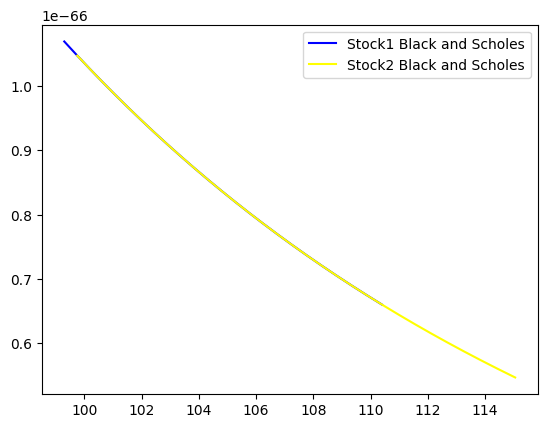

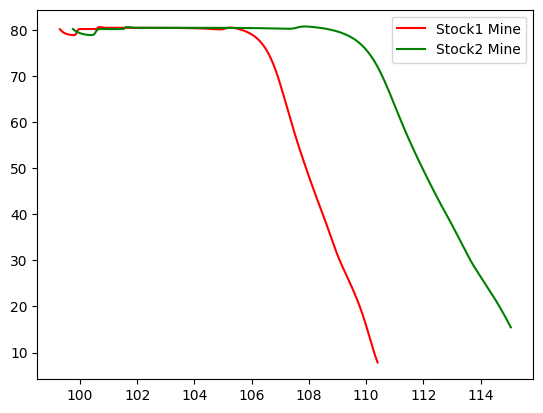

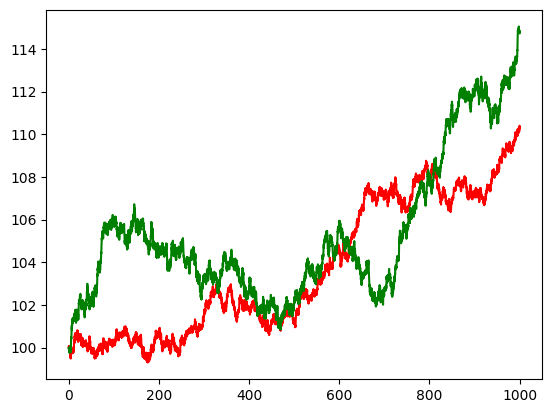

In [70]:
model.eval()

# Example: 5 specific points in time and space
t_vals  = np.linspace(0,1000,10000)
y1_vals = 100+np.cumsum(np.random.randn(10000)*0.05+0.001)
y2_vals = 100+np.cumsum(np.random.randn(10000)*0.07+0.002)
y1_vals=np.clip(y1_vals,0,200)
y2_vals=np.clip(y2_vals,0,200)
y1min=min(y1_vals)
y2min=min(y2_vals)
y1max=max(y1_vals)
y2max=max(y2_vals)
y1=np.linspace(y1min,y1max,10000)
y2=np.linspace(y2min,y2max,10000)


with torch.no_grad():
    # Convert to tensors and reshape to (N, 1) column vectors
    t_tensor  = torch.tensor(t_vals, dtype=torch.float32).view(-1, 1)
    y1_tensor = torch.tensor(y1, dtype=torch.float32).view(-1, 1)
    y2_tensor = torch.tensor(y2, dtype=torch.float32).view(-1, 1)
    w_preds1=model.forward(t_tensor,y1_tensor,y2_tensor)
    w_preds2=model.forward(t_tensor,y2_tensor,y1_tensor)

plt.plot(y1,black_scholes(y1),color="blue",label="Stock1 Black and Scholes")
plt.plot(y2,black_scholes(y2),color="yellow",label="Stock2 Black and Scholes")
plt.legend()
plt.show()
plt.plot(y1,w_preds1,color="red",label="Stock1 Mine")
plt.plot(y2,w_preds2,color="green",label="Stock2 Mine")
plt.legend()
plt.show()
plt.plot(t_vals,y1_vals,color="red")
plt.plot(t_vals,y2_vals,color="green")
plt.show()